In [1]:
import pandas as pd

df = pd.read_csv("results/results_imagenette/results.csv")
df

,idx,problem,original_score,best_score_black,best_score_inpaint,best_score_cutting_black,quantity_score_black,quantity_score_inpaint,quantity_score_cutting_black,probability_score_black,probability_score_inpaint,probability_score_cutting_black,threshold
0,860,menor_probabilidade_menor_area_v,1.0,0.0498,0.9947,0.6027,0.0749,0.9956,0.9610,0.0222,0.9880,0.9900,0.1
1,860,poligono_e_perimetro_v,1.0,0.0348,1.0000,0.2240,0.0781,0.9972,0.9957,0.4869,0.9996,0.6137,0.1
2,860,menor_probabilidade_menor_area_inpaint_v,1.0,0.5179,0.1787,0.9999,0.9005,0.2820,1.0000,0.5815,0.0251,1.0000,0.1
3,860,poligono_e_perimetro_com_inpaint_v,1.0,0.5884,0.3602,0.4144,0.5973,0.2422,0.9924,0.6632,0.3567,0.8047,0.1
4,860,ipha_flavio_marcelo_v,1.0,0.9896,0.9999,0.8282,0.9896,0.9999,0.8282,0.9896,0.9999,0.8282,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,400,menor_probabilidade_menor_area_v,1.0,0.0000,0.8321,0.0024,0.0027,0.9927,0.0108,0.0001,0.9893,0.0100,0.1
996,400,poligono_e_perimetro_v,1.0,0.0001,0.6975,0.0087,0.0743,0.2678,0.5294,0.4400,0.4363,0.2740,0.1
997,400,menor_probabilidade_menor_area_inpaint_v,1.0,0.0145,0.0186,0.7658,0.1153,0.1477,0.8758,0.0393,0.0103,0.8065,0.1
998,400,poligono_e_perimetro_com_inpaint_v,1.0,0.0317,0.0358,0.1197,0.0444,0.2004,0.9754,0.0062,0.3622,0.4858,0.1


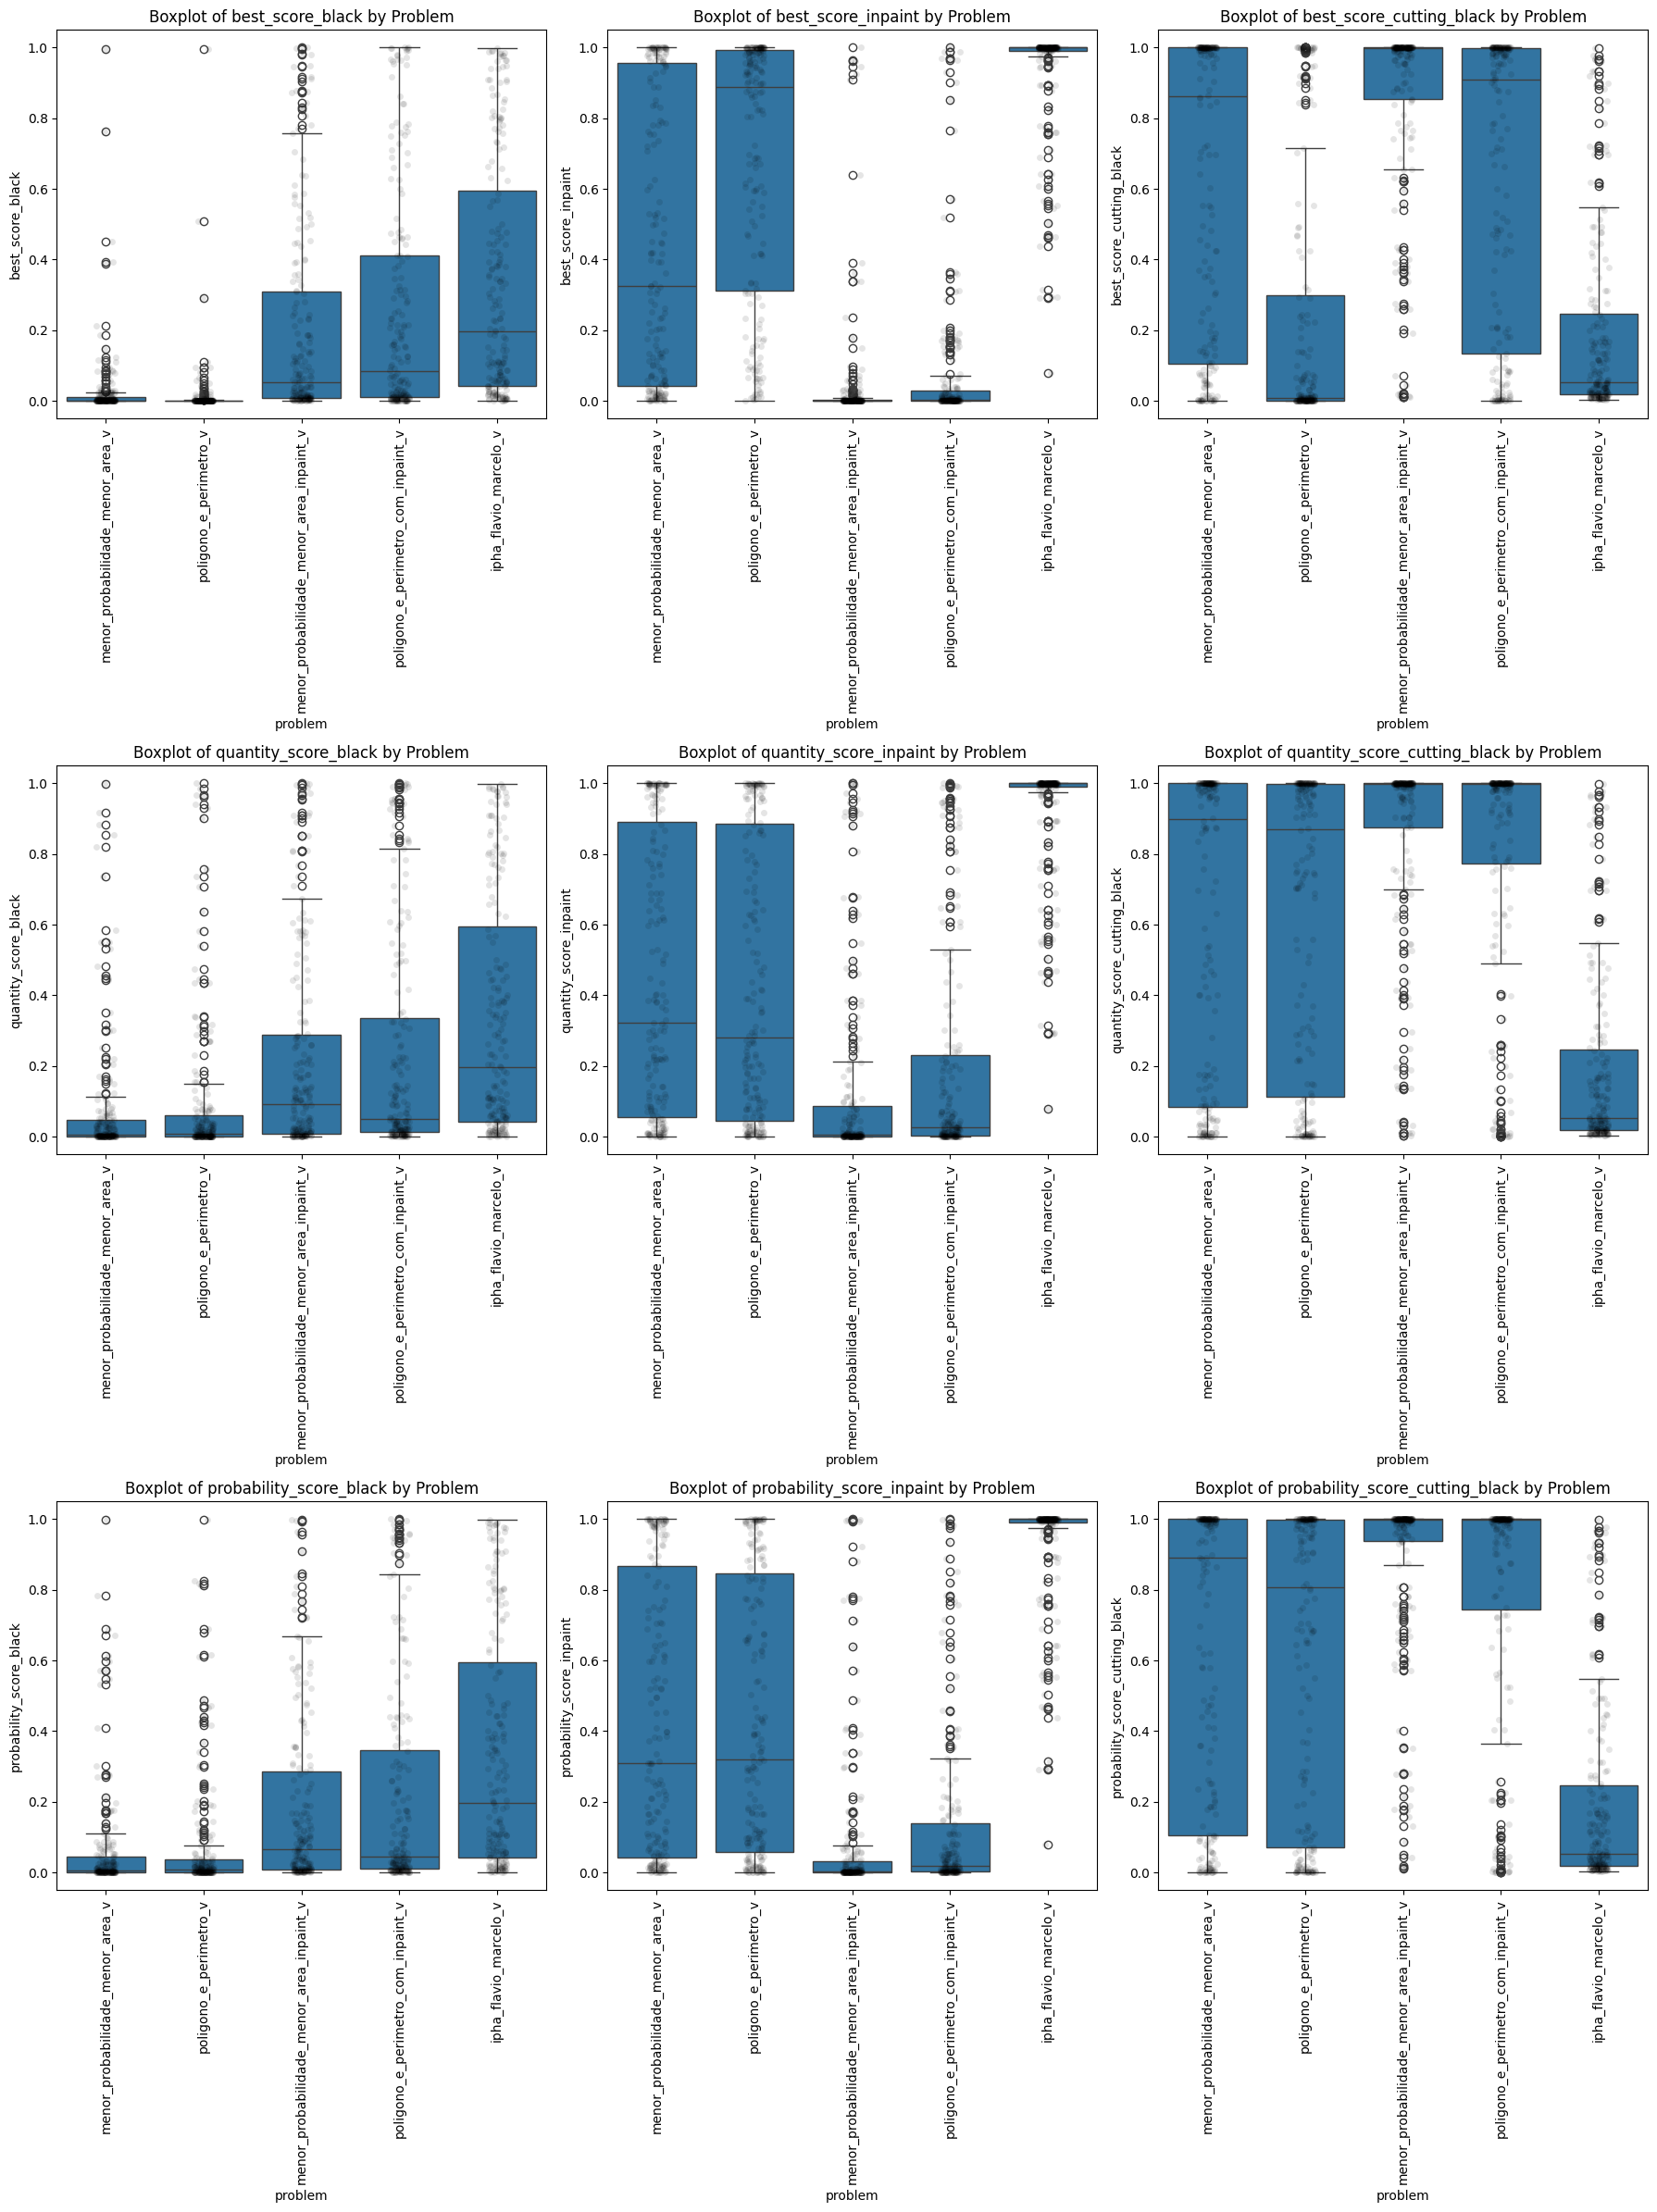

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

y_vars = [
    'best_score_black', 'best_score_inpaint', 'best_score_cutting_black',
    'quantity_score_black', 'quantity_score_inpaint', 'quantity_score_cutting_black',
    'probability_score_black', 'probability_score_inpaint', 'probability_score_cutting_black'
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 24))
axes = axes.flatten()

for i, y in enumerate(y_vars):
    sns.boxplot(x='problem', y=y, data=df, ax=axes[i])
    sns.stripplot(x='problem', y=y, data=df, ax=axes[i], color='black', jitter=True, size=5, alpha=0.1)
    axes[i].set_title(f'Boxplot of {y} by Problem')
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [7]:
# Mostrar medias e desvios padrão
summary = df.groupby('problem')[y_vars].agg(['mean', 'std'])

# Exibir como tabela, linhas são os problemas, colunas são as métricas
print(summary)

                                         best_score_black            \
                                                     mean       std   
problem                                                               
ipha_flavio_marcelo_v                            0.333978  0.336390   
menor_probabilidade_menor_area_inpaint_v         0.205404  0.287147   
menor_probabilidade_menor_area_v                 0.027782  0.103809   
poligono_e_perimetro_com_inpaint_v               0.254328  0.323922   
poligono_e_perimetro_v                           0.013721  0.082495   

                                         best_score_inpaint            \
                                                       mean       std   
problem                                                                 
ipha_flavio_marcelo_v                              0.932091  0.165729   
menor_probabilidade_menor_area_inpaint_v           0.046904  0.174658   
menor_probabilidade_menor_area_v                   0.450524  0.406

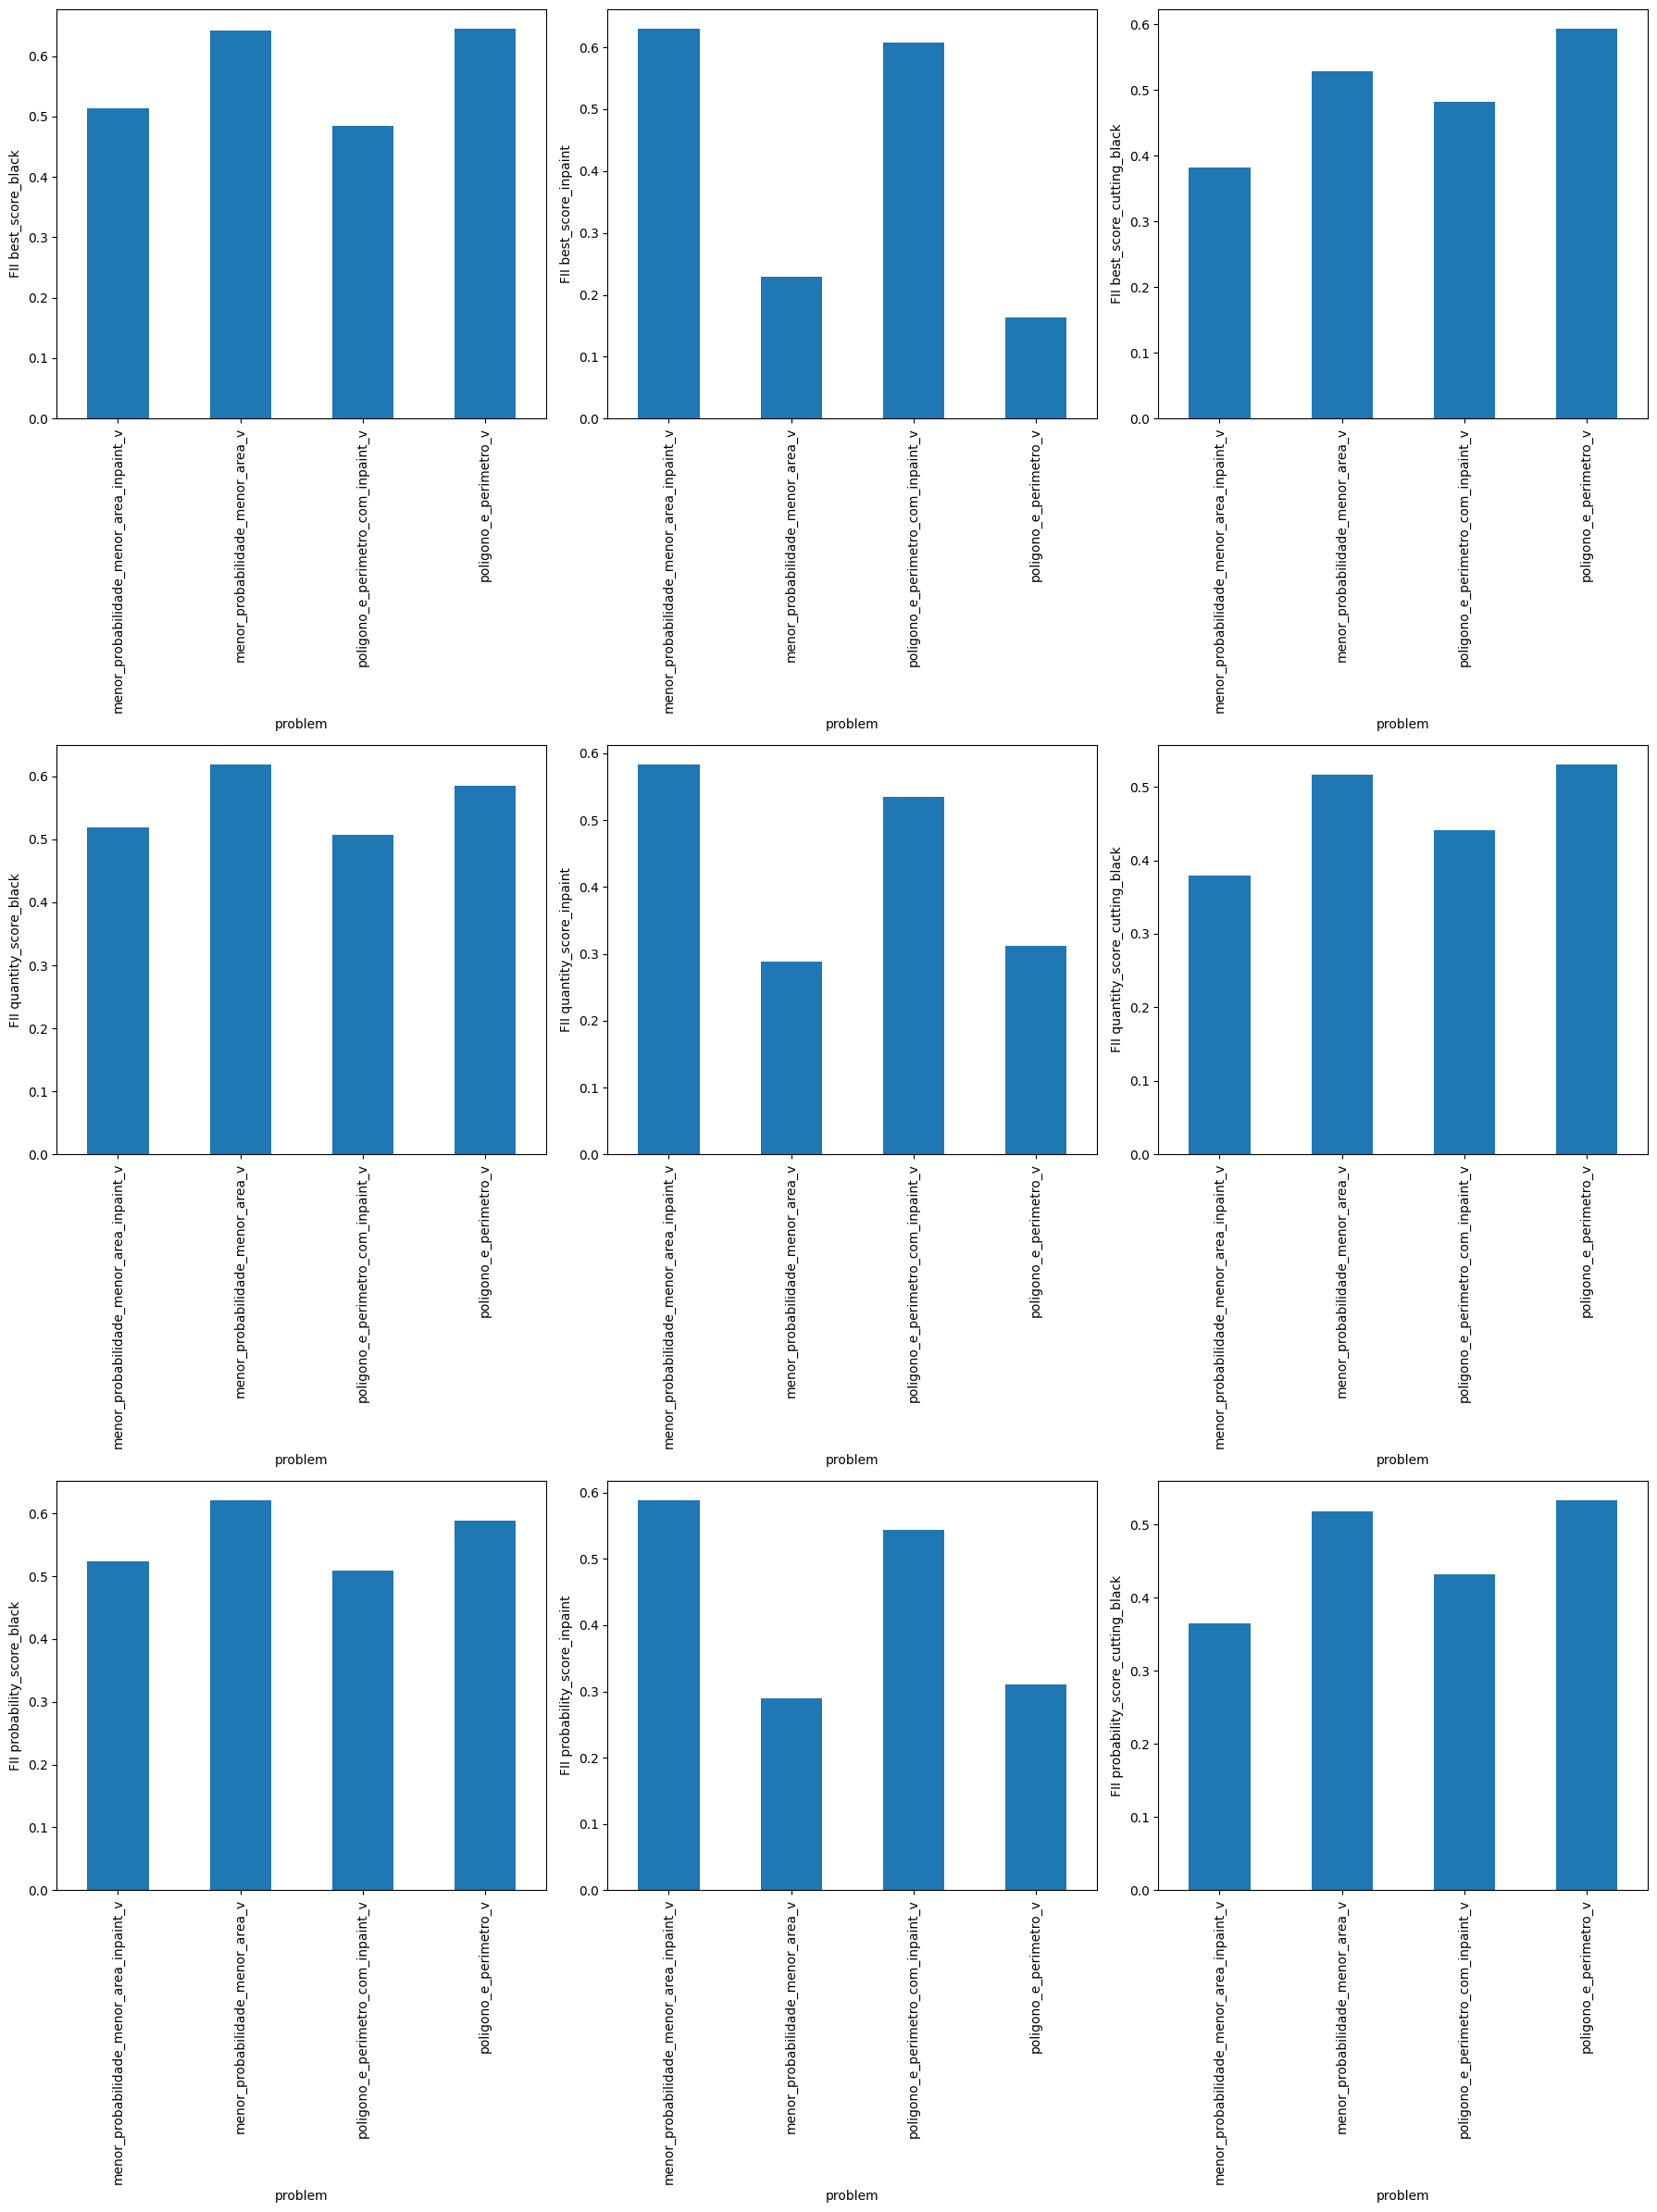

In [8]:
import matplotlib.pyplot as plt



import matplotlib.pyplot as plt
import seaborn as sns

y_vars = [
    'best_score_black', 'best_score_inpaint', 'best_score_cutting_black',
    'quantity_score_black', 'quantity_score_inpaint', 'quantity_score_cutting_black',
    'probability_score_black', 'probability_score_inpaint', 'probability_score_cutting_black'
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 24))
axes = axes.flatten()

for i, y in enumerate(y_vars):
    diff_by_problem = (
        df.assign(diff=(df['original_score'] - df[y]).abs())
          .groupby('problem')['diff']
          .mean()
          .reset_index(name='mean_abs_diff')
    )
    diff_by_problem.plot.bar(x='problem', y='mean_abs_diff', legend=False, ax=axes[i], color='tab:blue')
    axes[i].set_ylabel(f"FII {y}")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

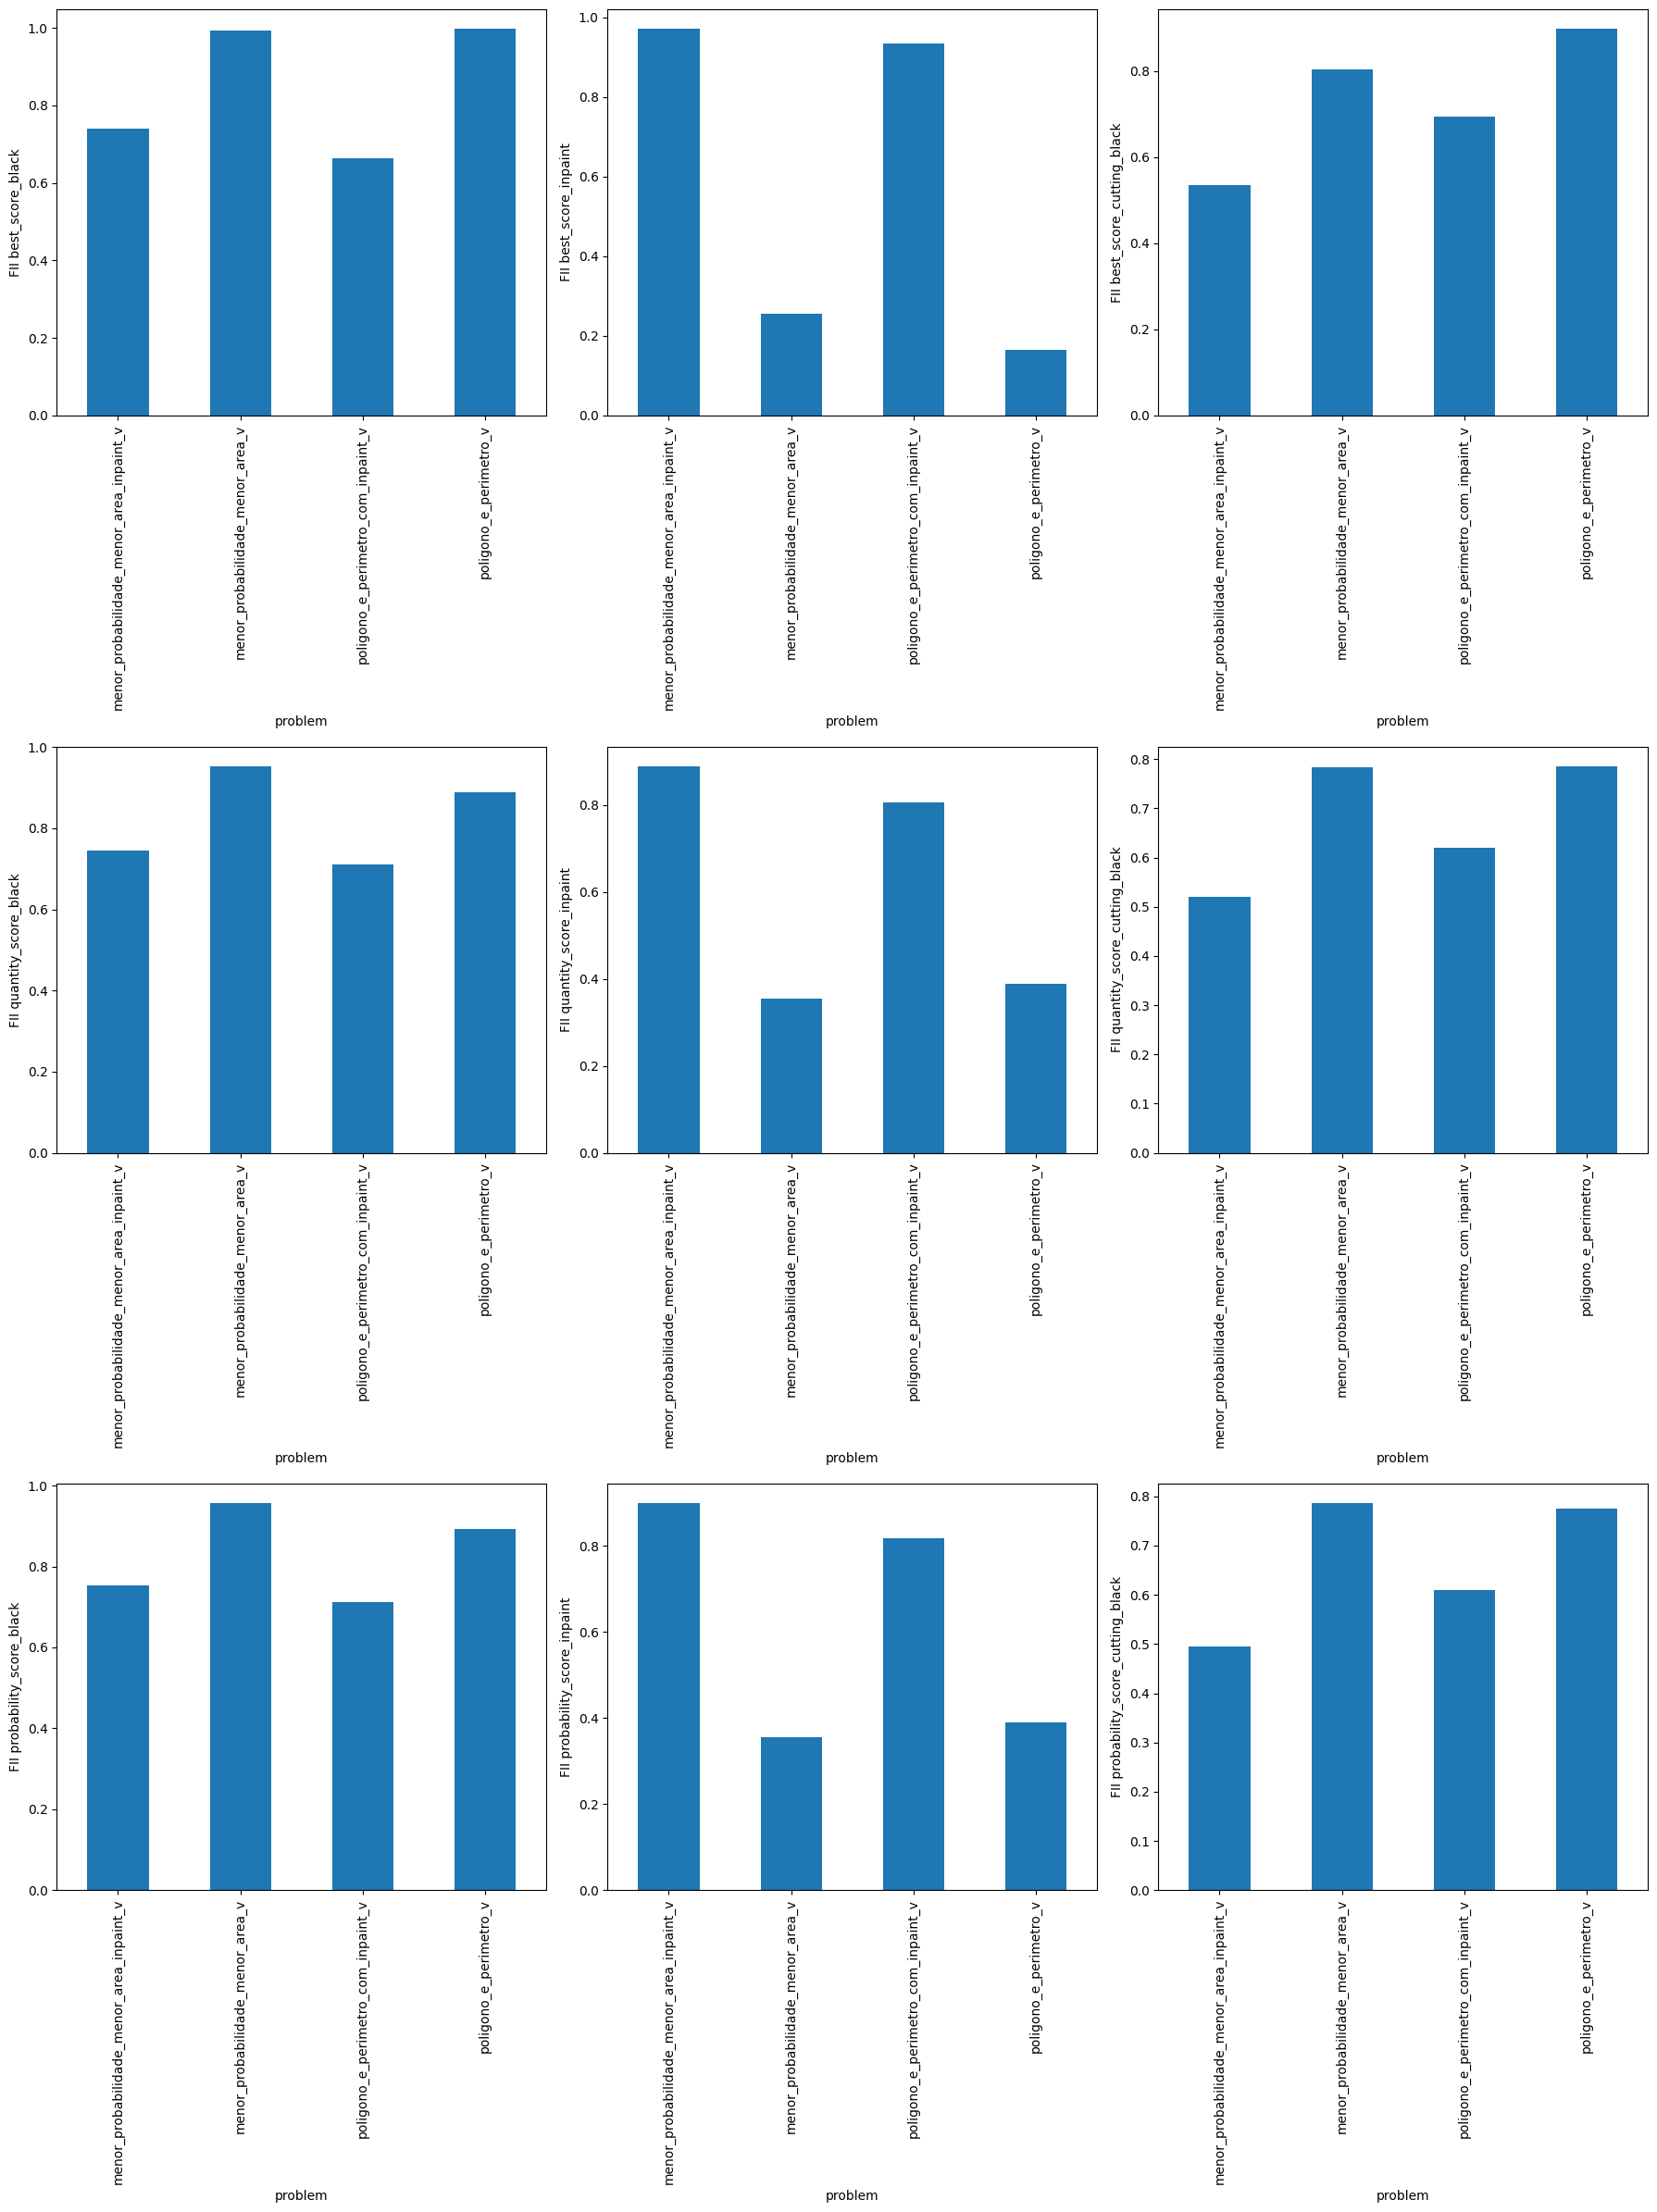

In [3]:
import matplotlib.pyplot as plt



import matplotlib.pyplot as plt
import seaborn as sns

y_vars = [
    'best_score_black', 'best_score_inpaint', 'best_score_cutting_black',
    'quantity_score_black', 'quantity_score_inpaint', 'quantity_score_cutting_black',
    'probability_score_black', 'probability_score_inpaint', 'probability_score_cutting_black'
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 24))
axes = axes.flatten()

for i, y in enumerate(y_vars):
    diff_by_problem = (
        df.assign(diff=((df['original_score'] - df[y]) / df['original_score']))
          .groupby('problem')['diff']
          .mean()
          .reset_index(name='mean_abs_diff')
    )
    diff_by_problem.plot.bar(x='problem', y='mean_abs_diff', legend=False, ax=axes[i], color='tab:blue')
    axes[i].set_ylabel(f"FII {y}")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

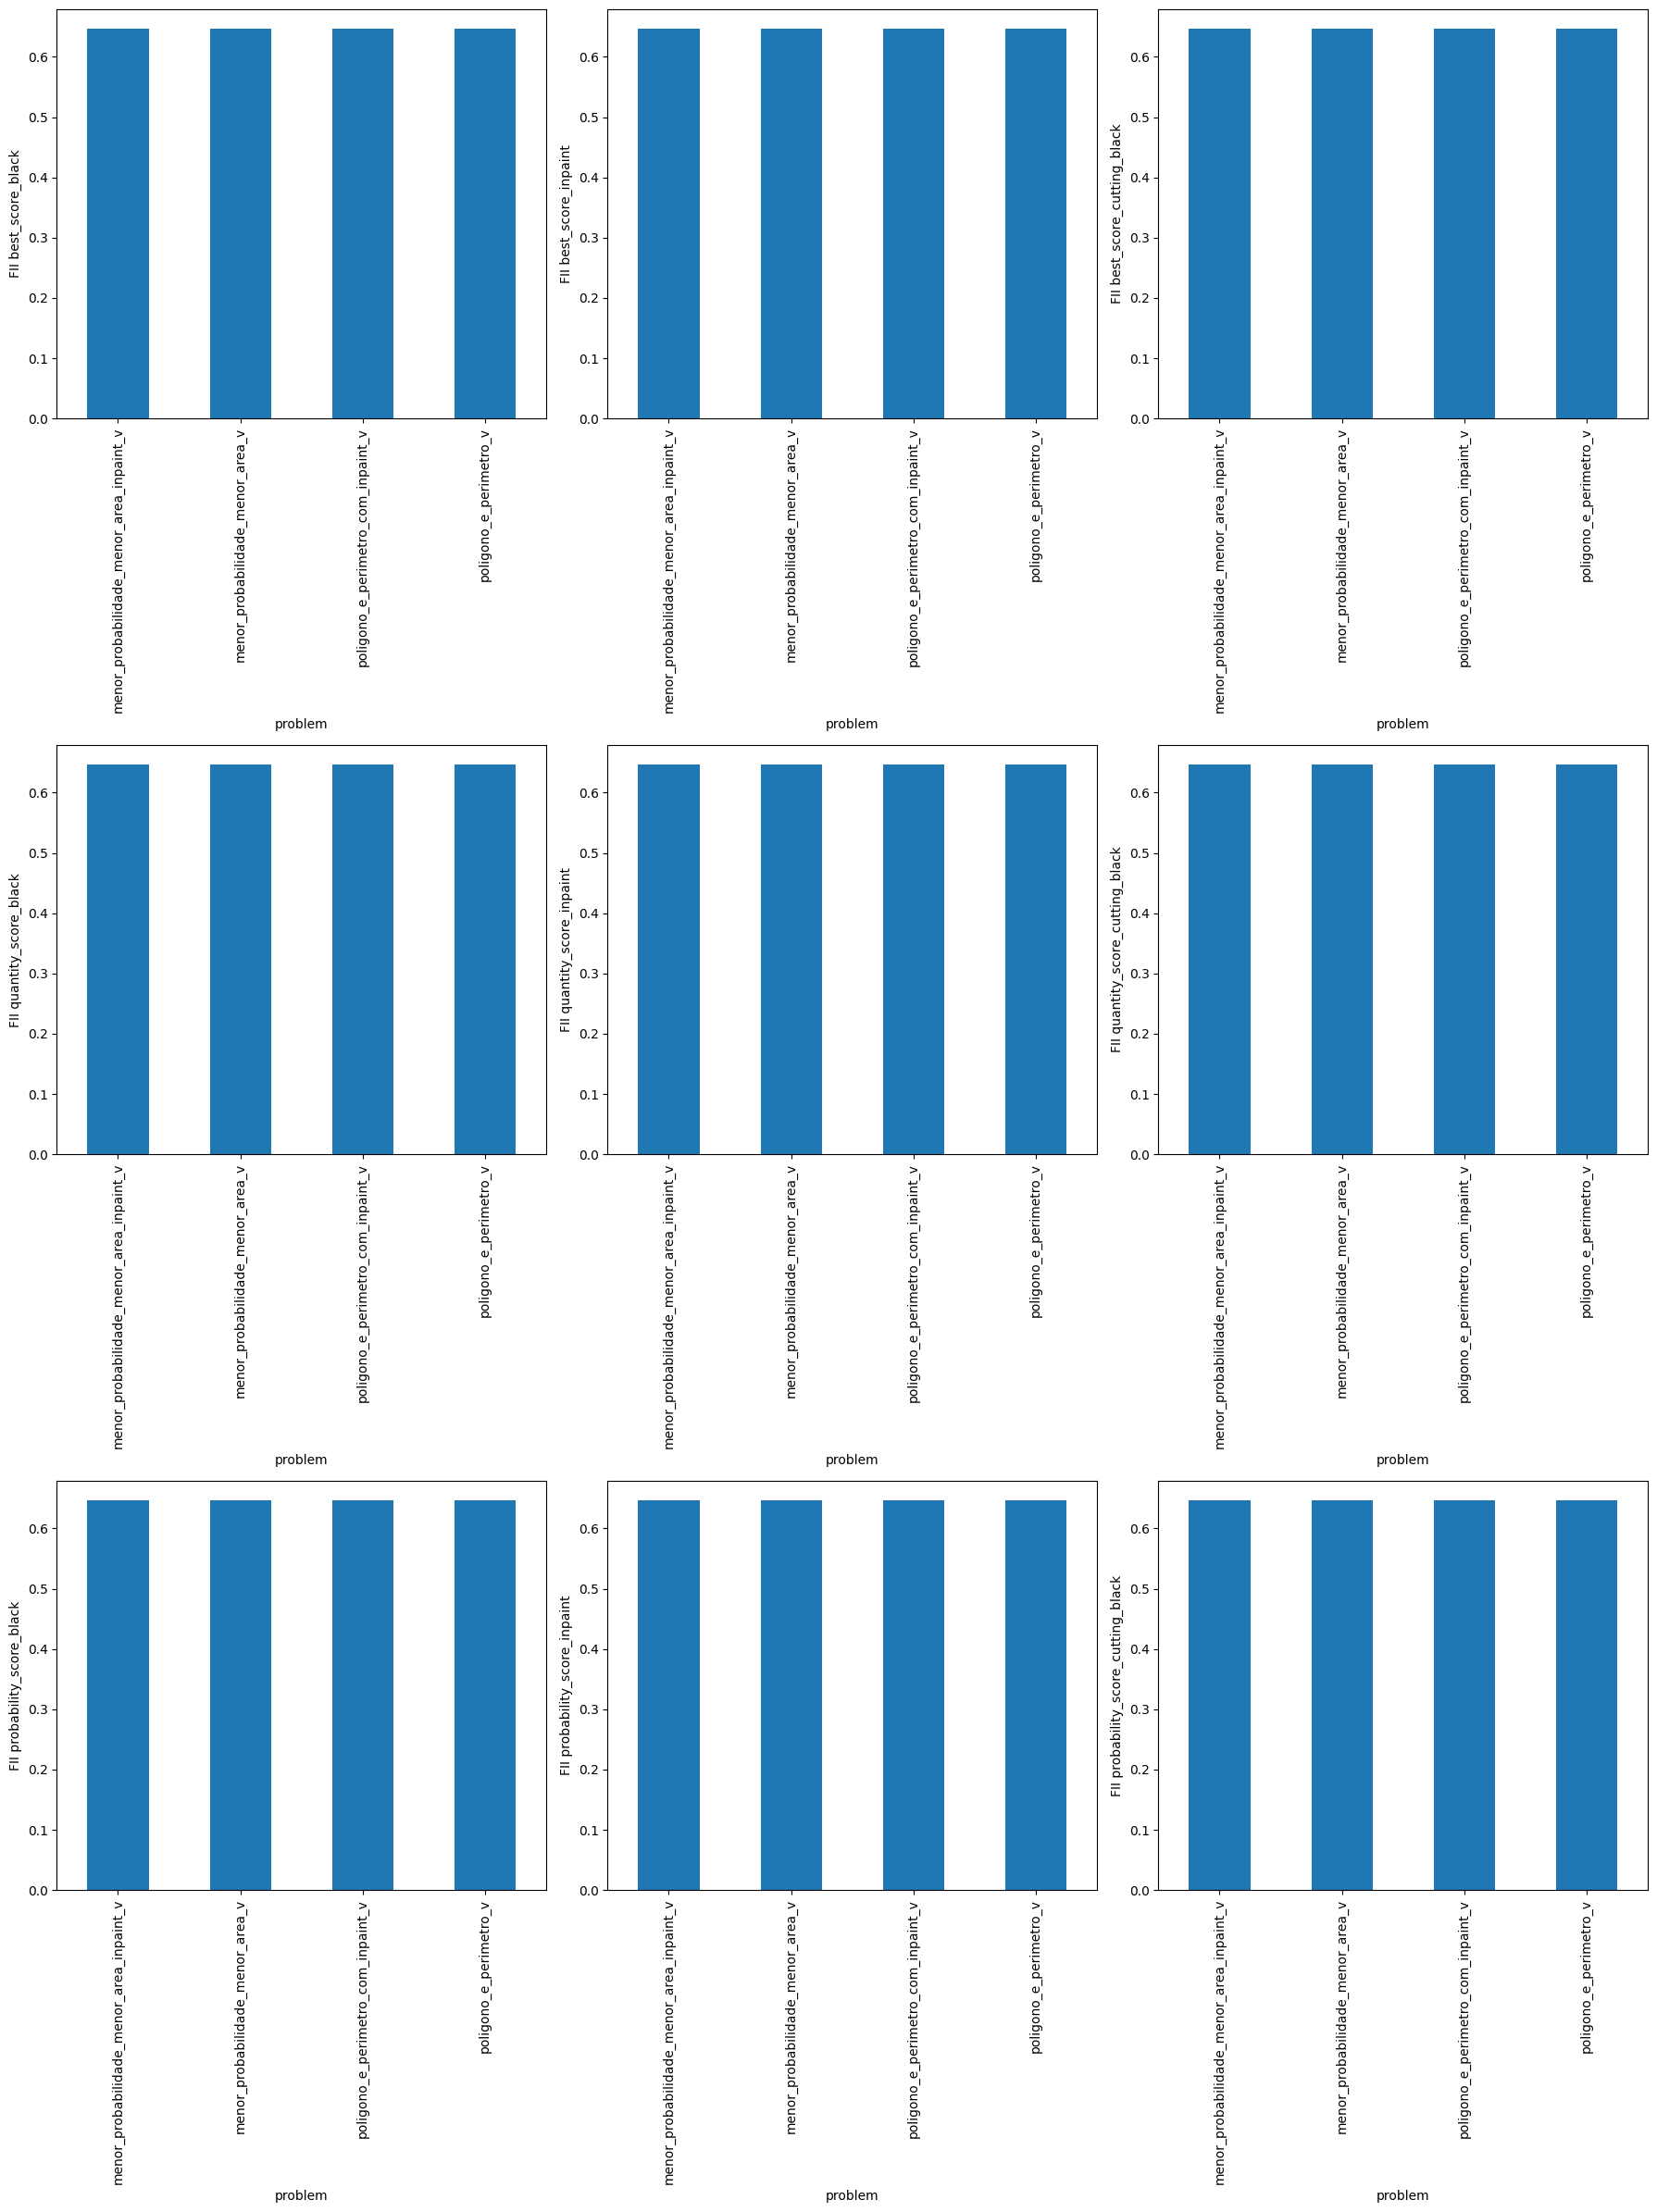

In [14]:
import matplotlib.pyplot as plt



import matplotlib.pyplot as plt
import seaborn as sns

y_vars = [
    'best_score_black', 'best_score_inpaint', 'best_score_cutting_black',
    'quantity_score_black', 'quantity_score_inpaint', 'quantity_score_cutting_black',
    'probability_score_black', 'probability_score_inpaint', 'probability_score_cutting_black'
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 24))
axes = axes.flatten()

for i, y in enumerate(y_vars):
    diff_by_problem = (
        df.assign(diff=(df['original_score']))
          .groupby('problem')['diff']
          .mean()
          .reset_index(name='mean_abs_diff')
    )
    diff_by_problem.plot.bar(x='problem', y='mean_abs_diff', legend=False, ax=axes[i], color='tab:blue')
    axes[i].set_ylabel(f"FII {y}")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

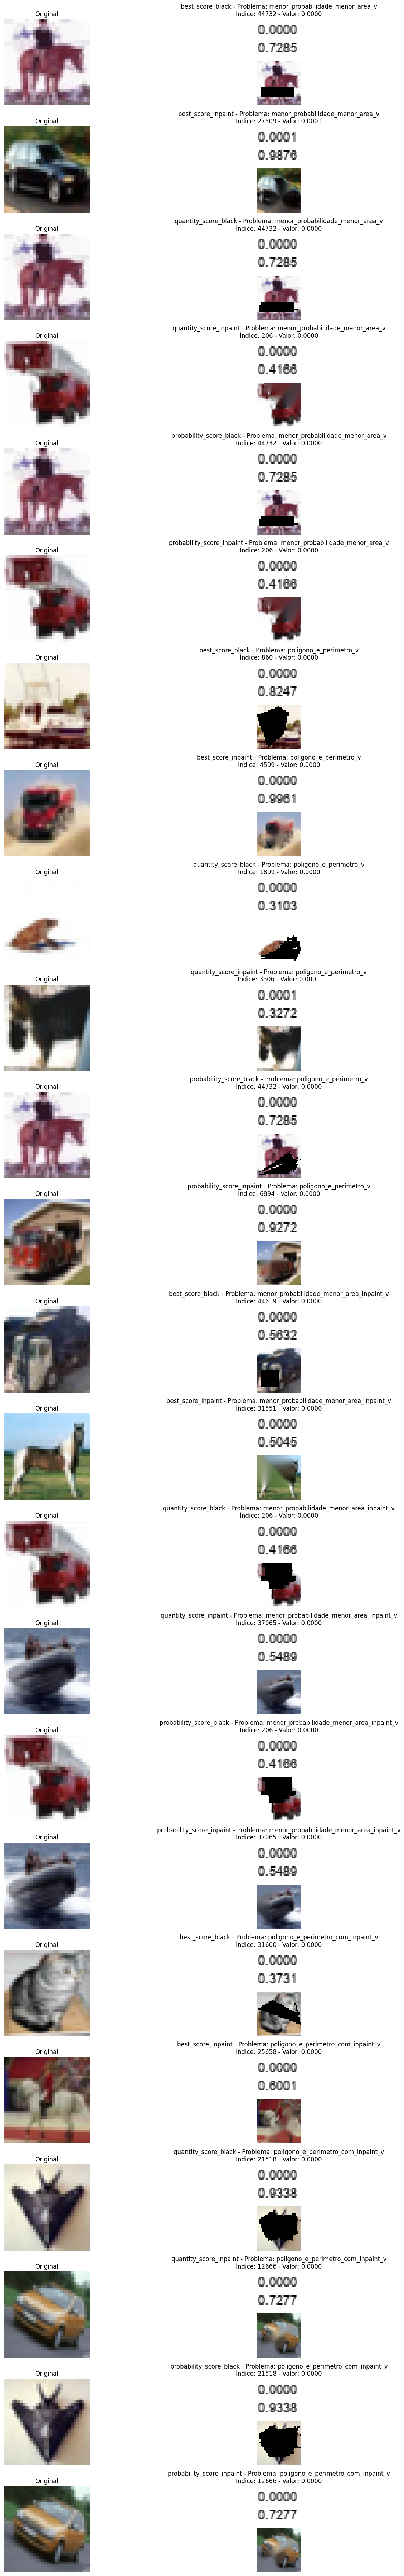

In [9]:
y_vars = [
    'best_score_black', 'best_score_inpaint',
    'quantity_score_black', 'quantity_score_inpaint',
    'probability_score_black', 'probability_score_inpaint',
]

y_image_names = [
    'best_black', 'best_inpaint',
    'masked_black_quantity', 'masked_inpaint_quantity',
    'masked_black_probability', 'masked_inpaint_probability',
]

fig, axes = plt.subplots(nrows=24, ncols=2, figsize=(18, 72))
axes = axes.flatten()

unique_problems = df['problem'].unique()
num_problems = len(unique_problems)
num_vars = len(y_vars)
for j in range(num_problems):
    problem = unique_problems[j]
    # print(f"\nProblema: {problem}")
    df_problem = df[df['problem'] == problem]
    for i in range(num_vars):
        y = y_vars[i]
        y_image_name = y_image_names[i]
        min_idx = df_problem[y].idxmin()
        min_val = df_problem.loc[min_idx, y]
        min_idx = df_problem.loc[min_idx, 'idx']
        # print(f"{y}: índice com menor valor = {min_idx}, valor = {min_val}")
        #show image in results_test_6/{min_idx}/{problem}/{y_image_name}.png
        original_img_path = f"results_test_6/{min_idx}/original.png"
        img_path = f"results_test_6/{min_idx}/{problem}/{y_image_name}.png"
        img = plt.imread(img_path)
        axes[2*(i + j * num_vars) + 0].imshow(plt.imread(original_img_path))
        axes[2*(i + j * num_vars) + 0].set_title(f'Original')
        axes[2*(i + j * num_vars) + 0].axis('off')
        axes[2*(i + j * num_vars) + 1].imshow(img)
        axes[2*(i + j * num_vars) + 1].set_title(f'{y} - Problema: {problem}\nÍndice: {min_idx} - Valor: {min_val:.4f}')
        axes[2*(i + j * num_vars) + 1].axis('off')

plt.tight_layout()
plt.show()

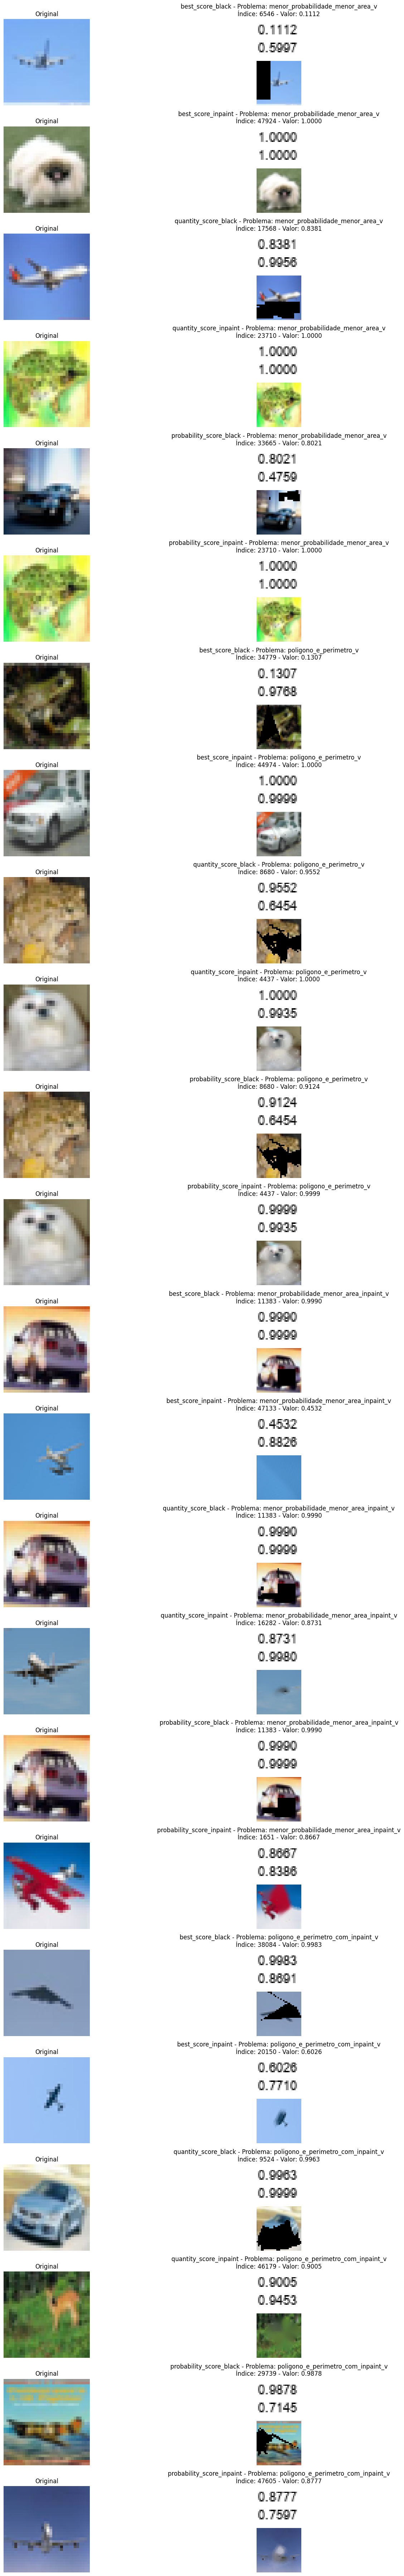

In [10]:
y_vars = [
    'best_score_black', 'best_score_inpaint',
    'quantity_score_black', 'quantity_score_inpaint',
    'probability_score_black', 'probability_score_inpaint',
]

y_image_names = [
    'best_black', 'best_inpaint',
    'masked_black_quantity', 'masked_inpaint_quantity',
    'masked_black_probability', 'masked_inpaint_probability',
]

fig, axes = plt.subplots(nrows=24, ncols=2, figsize=(18, 72))
axes = axes.flatten()

unique_problems = df['problem'].unique()
num_problems = len(unique_problems)
num_vars = len(y_vars)
for j in range(num_problems):
    problem = unique_problems[j]
    # print(f"\nProblema: {problem}")
    df_problem = df[df['problem'] == problem]
    for i in range(num_vars):
        y = y_vars[i]
        y_image_name = y_image_names[i]
        max_idx = df_problem[y].idxmax()
        max_val = df_problem.loc[max_idx, y]
        max_idx = df_problem.loc[max_idx, 'idx']
        # print(f"{y}: índice com menor valor = {max_idx}, valor = {max_val}")
        #show image in results_test_6/{max_idx}/{problem}/{y_image_name}.png
        original_img_path = f"results_test_6/{max_idx}/original.png"
        img_path = f"results_test_6/{max_idx}/{problem}/{y_image_name}.png"
        img = plt.imread(img_path)
        axes[2*(i + j * num_vars) + 0].imshow(plt.imread(original_img_path))
        axes[2*(i + j * num_vars) + 0].set_title(f'Original')
        axes[2*(i + j * num_vars) + 0].axis('off')
        axes[2*(i + j * num_vars) + 1].imshow(img)
        axes[2*(i + j * num_vars) + 1].set_title(f'{y} - Problema: {problem}\nÍndice: {max_idx} - Valor: {max_val:.4f}')
        axes[2*(i + j * num_vars) + 1].axis('off')

plt.tight_layout()
plt.show()

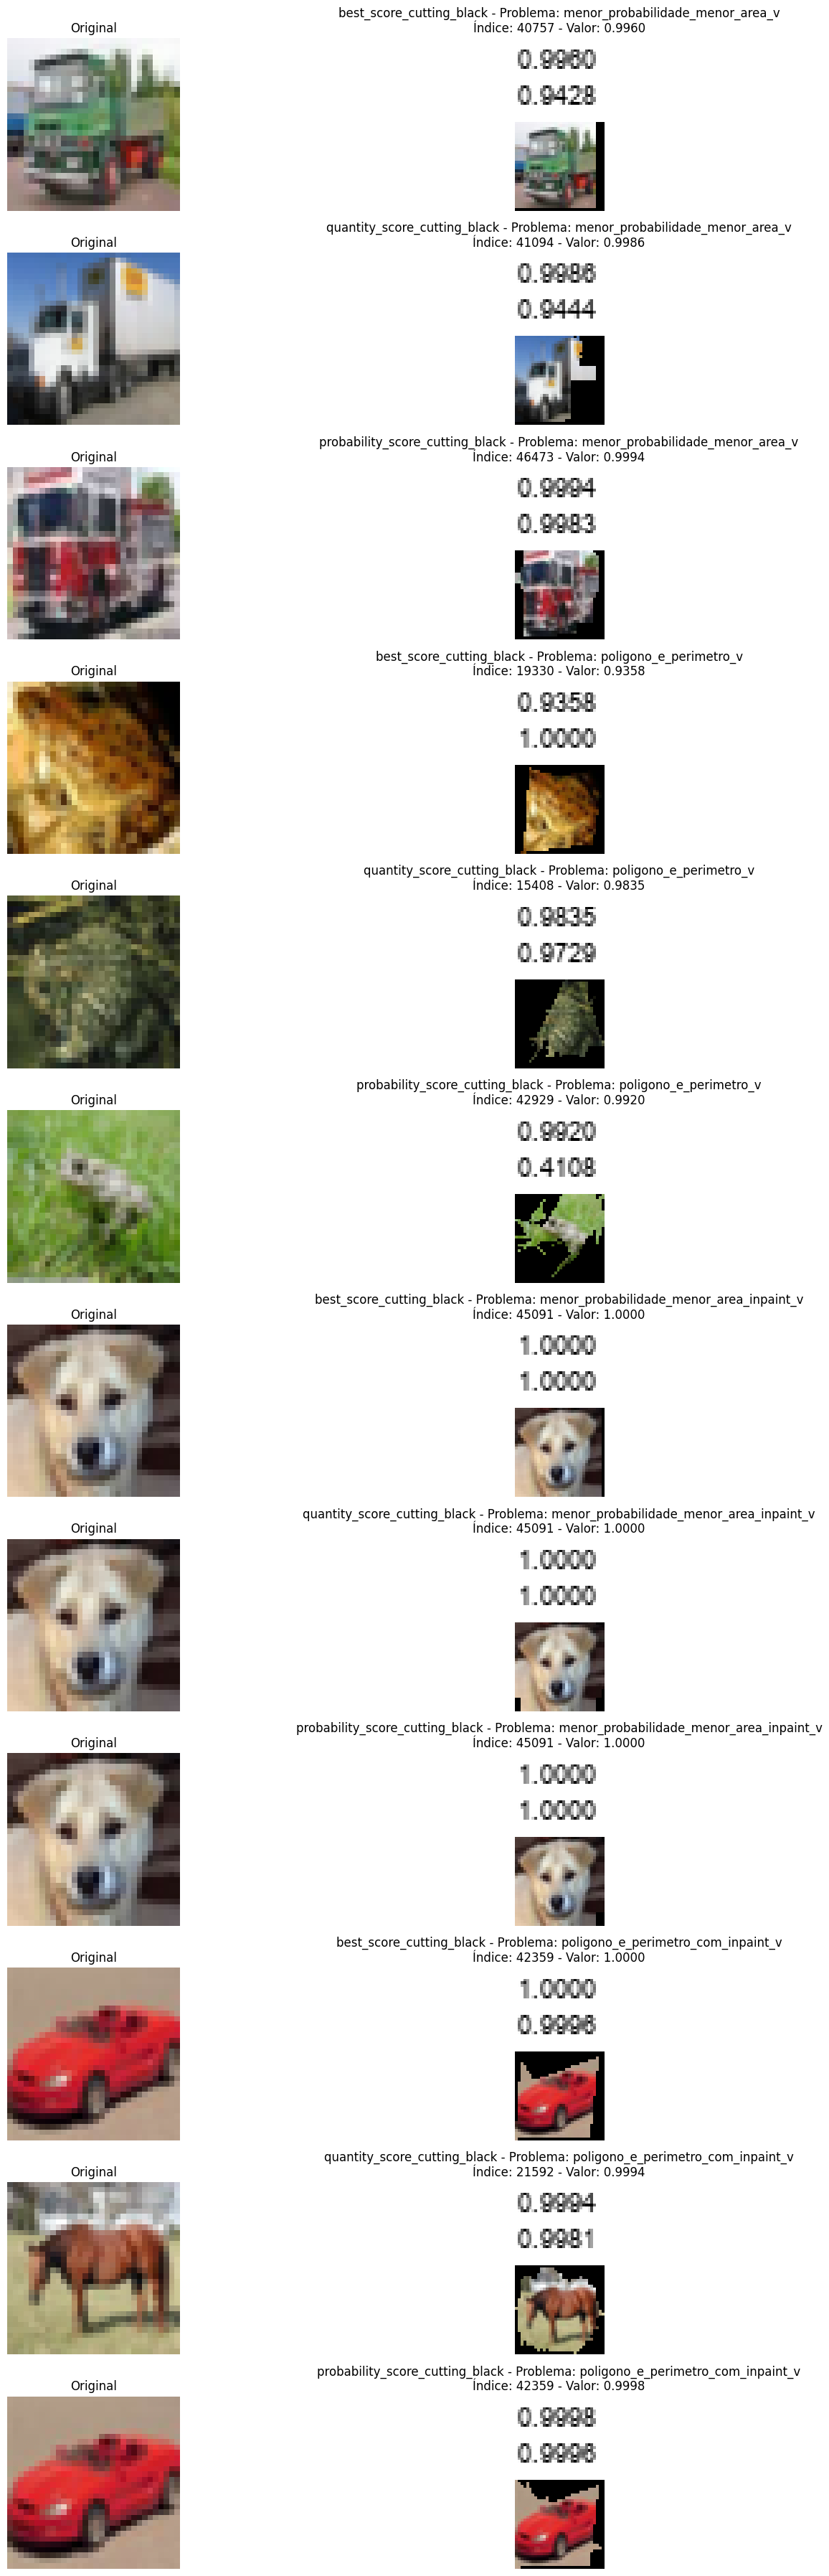

In [11]:
y_vars = [
    'best_score_cutting_black',
    'quantity_score_cutting_black',
    'probability_score_cutting_black'
]

y_image_names = [
    'best_cutted_black',
    'masked_cutting_black_quantity',
    'masked_cutting_black_probability',
]

fig, axes = plt.subplots(nrows=12, ncols=2, figsize=(18, 36))
axes = axes.flatten()

unique_problems = df['problem'].unique()
num_problems = len(unique_problems)
num_vars = len(y_vars)
for j in range(num_problems):
    problem = unique_problems[j]
    # print(f"\nProblema: {problem}")
    df_problem = df[df['problem'] == problem]
    for i in range(num_vars):
        y = y_vars[i]
        y_image_name = y_image_names[i]
        min_idx = df_problem[y].idxmax()
        min_val = df_problem.loc[min_idx, y]
        min_idx = df_problem.loc[min_idx, 'idx']
        # print(f"{y}: índice com menor valor = {min_idx}, valor = {min_val}")
        #show image in results_test_6/{min_idx}/{problem}/{y_image_name}.png
        original_img_path = f"results_test_6/{min_idx}/original.png"
        img_path = f"results_test_6/{min_idx}/{problem}/{y_image_name}.png"
        img = plt.imread(img_path)
        axes[2*(i + j * num_vars) + 0].imshow(plt.imread(original_img_path))
        axes[2*(i + j * num_vars) + 0].set_title(f'Original')
        axes[2*(i + j * num_vars) + 0].axis('off')
        axes[2*(i + j * num_vars) + 1].imshow(img)
        axes[2*(i + j * num_vars) + 1].set_title(f'{y} - Problema: {problem}\nÍndice: {min_idx} - Valor: {min_val:.4f}')
        axes[2*(i + j * num_vars) + 1].axis('off')

plt.tight_layout()
plt.show()

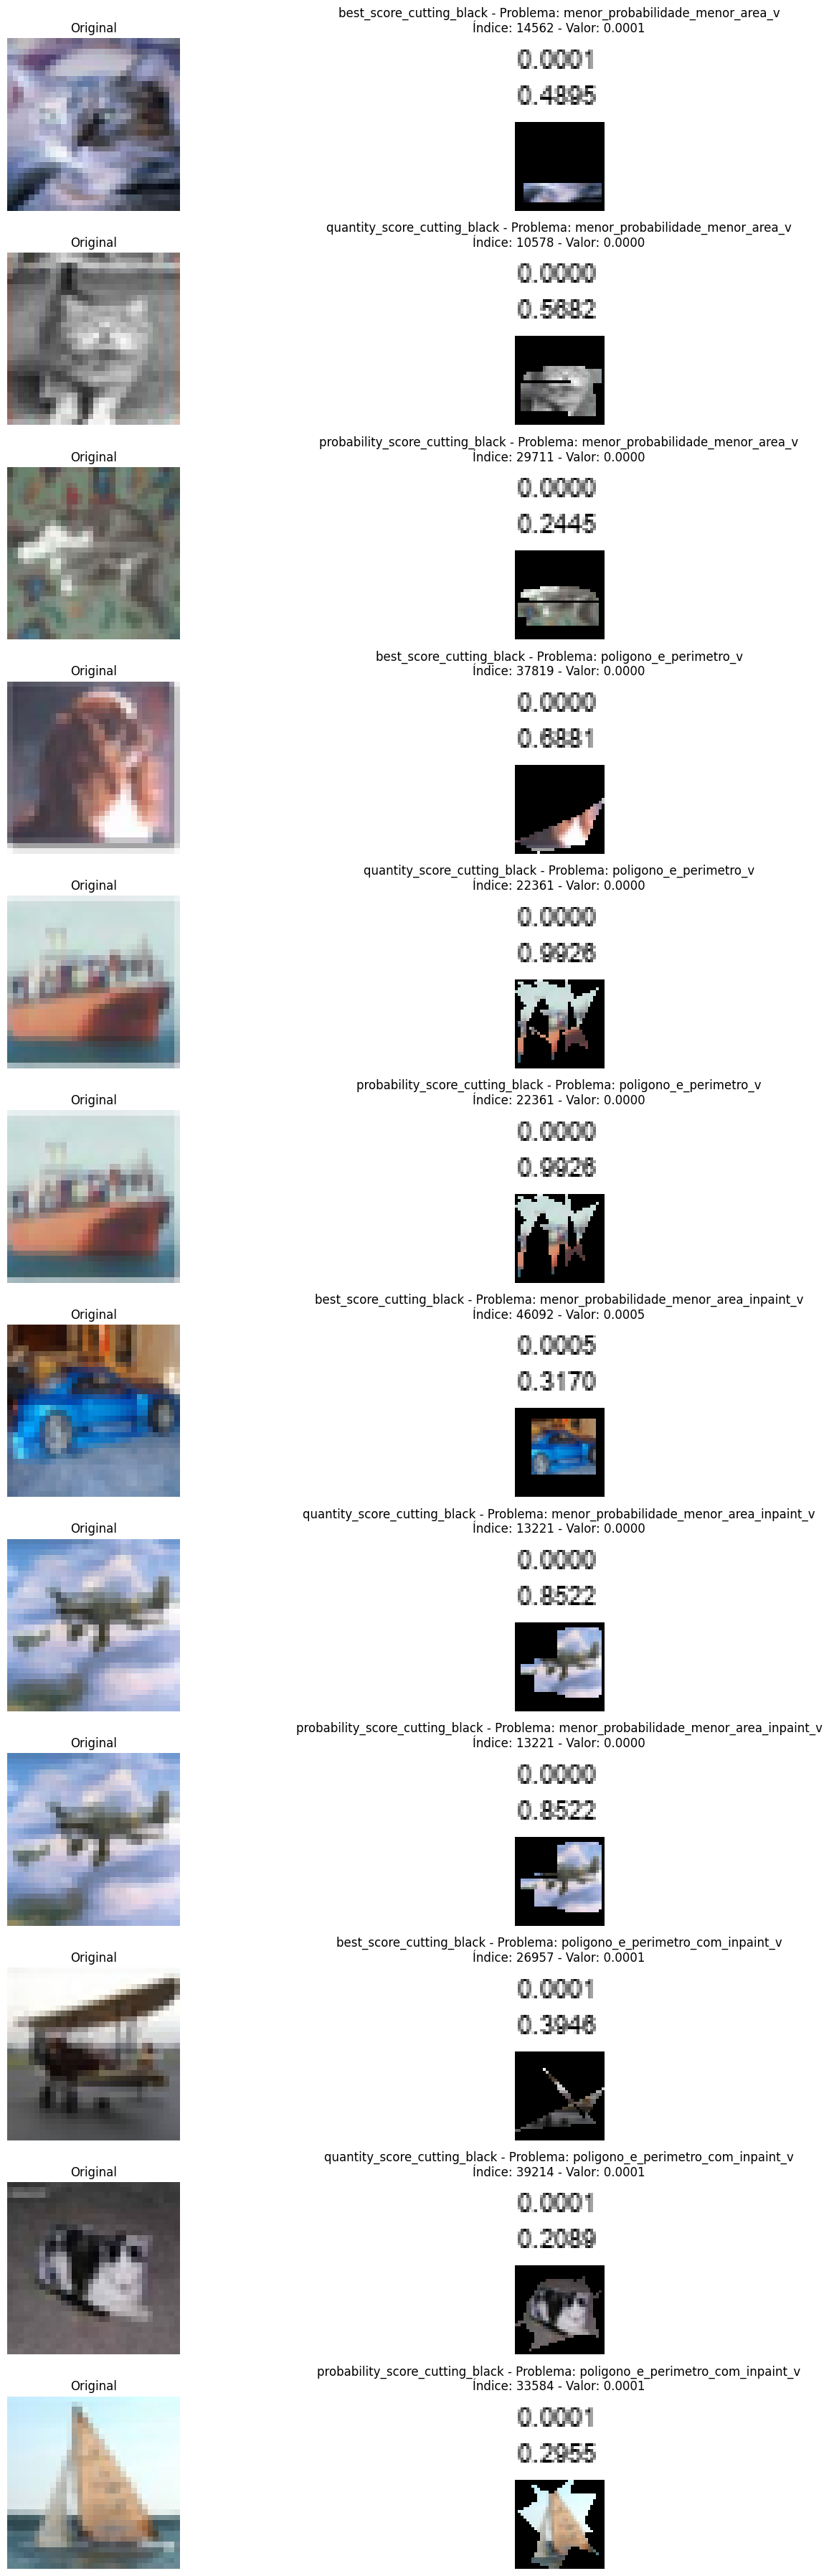

In [12]:
y_vars = [
    'best_score_cutting_black',
    'quantity_score_cutting_black',
    'probability_score_cutting_black'
]

y_image_names = [
    'best_cutted_black',
    'masked_cutting_black_quantity',
    'masked_cutting_black_probability',
]

fig, axes = plt.subplots(nrows=12, ncols=2, figsize=(18, 36))
axes = axes.flatten()

unique_problems = df['problem'].unique()
num_problems = len(unique_problems)
num_vars = len(y_vars)
for j in range(num_problems):
    problem = unique_problems[j]
    # print(f"\nProblema: {problem}")
    df_problem = df[df['problem'] == problem]
    for i in range(num_vars):
        y = y_vars[i]
        y_image_name = y_image_names[i]
        min_idx = df_problem[y].idxmin()
        min_val = df_problem.loc[min_idx, y]
        min_idx = df_problem.loc[min_idx, 'idx']
        # print(f"{y}: índice com menor valor = {min_idx}, valor = {min_val}")
        #show image in results_test_6/{min_idx}/{problem}/{y_image_name}.png
        original_img_path = f"results_test_6/{min_idx}/original.png"
        img_path = f"results_test_6/{min_idx}/{problem}/{y_image_name}.png"
        img = plt.imread(img_path)
        axes[2*(i + j * num_vars) + 0].imshow(plt.imread(original_img_path))
        axes[2*(i + j * num_vars) + 0].set_title(f'Original')
        axes[2*(i + j * num_vars) + 0].axis('off')
        axes[2*(i + j * num_vars) + 1].imshow(img)
        axes[2*(i + j * num_vars) + 1].set_title(f'{y} - Problema: {problem}\nÍndice: {min_idx} - Valor: {min_val:.4f}')
        axes[2*(i + j * num_vars) + 1].axis('off')

plt.tight_layout()
plt.show()